In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit
import sys
import scipy
import rasterio
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.stats import multivariate_normal
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

In [2]:
Russia_total= 15508
China_total= 9333
Argentina_total =7092
Brazil_total=9201
Spain_total=6340
France_total=9406

## sample 5000 pixels from complete USA database

In [3]:
usa_data=pd.read_csv('./database/updated_USA_file_final.csv')

In [4]:
train_lon=usa_data['Longitude in degrees'].to_numpy()
train_lat=usa_data['Latitude in degrees'].to_numpy()
train_pix=hp.ang2pix(128,train_lon,train_lat,lonlat=True)

In [5]:
test_pix=np.random.choice(train_pix,5000,replace=False)
finlon,finlat=hp.pix2ang(128,test_pix,lonlat=True)
finlon[finlon>180]-=360

## CDF of pixels

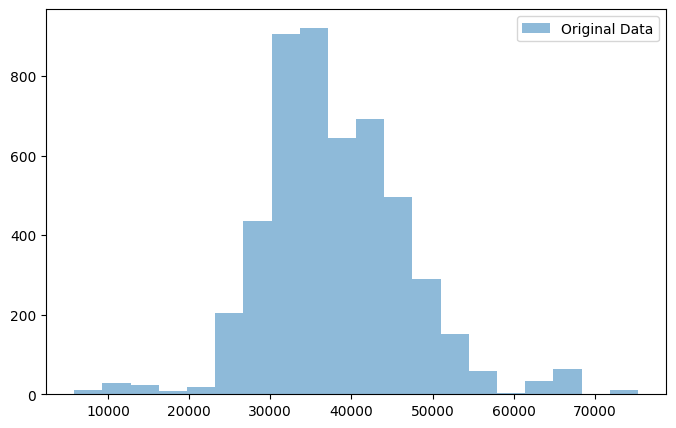

In [6]:
data = test_pix 

# Creating histogram to estimate the CDF
hist, bins = np.histogram(data, bins='fd', density=True)
cumulative = np.cumsum(hist * np.diff(bins))  # Estimating cumulative distribution function (CDF)

# Generating synthetic data based on the CDF
# synthetic_data = np.interp(np.random.uniform(0, 1, finval), cumulative, bins[:-1])

# Plotting original data and synthetic data
plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, alpha=0.5, label='Original Data')
# plt.hist(synthetic_data, bins=20, alpha=0.5, label='Synthetic Data')
plt.legend()
plt.show()


In [7]:
new_pix = np.interp(np.random.uniform(0, 1, 30000), cumulative, bins[:-1])


In [8]:
new_pix=np.array(new_pix)

In [9]:
new_pix=new_pix.astype(int)

In [14]:
tester=np.random.choice(train_pix,28263,replace=False)
long,lat=hp.pix2ang(128,tester,lonlat=True)
long[long>180]-=360

In [15]:
data={'Lon':long,'Lat':lat}
df=pd.DataFrame(data)
df.to_csv('/home/pratush/Documents/USA_max.csv')